In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#load dataset
#!pip install pandas openpyxl
df=pd.read_excel("Online_Retail.xlsx")

In [4]:
print("Top 5 rows:")
df.head()

Top 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Last 5 rows:")
df.tail()

Last 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [6]:
print("Shape of the df")
df.shape

Shape of the df


(541909, 8)

In [7]:
print(df.columns)
print(df.dtypes)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [8]:
#converting column InvoiceDate to Datetime

df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [9]:
#Data Cleaning
df.isnull().sum()

#customer ID and Description has many null values

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
#customerID
# #converting decimal values to int
df['CustomerID'] = df['CustomerID'].astype('Int64')

#using median to impute incorrect and null values
df['CustomerID']=df['CustomerID'].fillna(df['CustomerID'].median())

In [11]:
#Description
df['Description']=df['Description'].fillna(df['Description'].mode()[0])


In [12]:
#Remove Duplicates
df=df.drop_duplicates()
print(df.duplicated().sum())

0


In [13]:
#verifying the null values 
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [14]:
#Fix Invalid Values
#column Quantity

#rows which has values less than 0 and which are not cancelled items
bad_rows=(df[
    
      (df['Quantity'] < 0) & 
      (~df['InvoiceNo'].astype(str).str.startswith('C'))
]
)
print(bad_rows)
#deleting the bad rows from the df
df=df.drop(bad_rows.index)


       InvoiceNo StockCode                         Description  Quantity  \
2406      536589     21777  WHITE HANGING HEART T-LIGHT HOLDER       -10   
4347      536764    84952C  WHITE HANGING HEART T-LIGHT HOLDER       -38   
7188      536996     22712  WHITE HANGING HEART T-LIGHT HOLDER       -20   
7189      536997     22028  WHITE HANGING HEART T-LIGHT HOLDER       -20   
7190      536998     85067  WHITE HANGING HEART T-LIGHT HOLDER        -6   
...          ...       ...                                 ...       ...   
535333    581210     23395                               check       -26   
535335    581212     22578                                lost     -1050   
535336    581213     22576                               check       -30   
536908    581226     23090                             missing      -338   
538919    581422     23169                             smashed      -235   

               InvoiceDate  UnitPrice  CustomerID         Country  
2406   2010-12-01 1

In [15]:

negative_quantiy=(df[
    
      df['Quantity'] <= 0      
]
)

print(negative_quantiy)
df=df.drop(negative_quantiy.index)

       InvoiceNo StockCode                       Description  Quantity  \
141      C536379         D                          Discount        -1   
154      C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235      C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236      C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237      C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   
...          ...       ...                               ...       ...   
540449   C581490     23144   ZINC T-LIGHT HOLDER STARS SMALL       -11   
541541   C581499         M                            Manual        -1   
541715   C581568     21258        VICTORIAN SEWING BOX LARGE        -5   
541716   C581569     84978  HANGING HEART JAR T-LIGHT HOLDER        -1   
541717   C581569     20979     36 PENCILS TUBE RED RETROSPOT        -5   

               InvoiceDate  UnitPrice  CustomerID         Country  
141    2010-12-01 09:41:00      27.50      

In [15]:
#Invaild Price
#price cannot be negative,zero 

invalid_price=df[df['UnitPrice'] < 0]
print(invalid_price)
 #deleting these 2 rows which has negative price, weird stock code and description

df=df.drop(invalid_price.index)

       InvoiceNo StockCode      Description  Quantity         InvoiceDate  \
299983   A563186         B  Adjust bad debt         1 2011-08-12 14:51:00   
299984   A563187         B  Adjust bad debt         1 2011-08-12 14:52:00   

        UnitPrice  CustomerID         Country  
299983  -11062.06       15152  United Kingdom  
299984  -11062.06       15152  United Kingdom  


In [16]:
#there are 1174 rows with unit ptice 0. imputing them with median

median_price=df.loc[df['UnitPrice'] != 0, 'UnitPrice'].median()
df.loc[df['UnitPrice'] == 0, 'UnitPrice']=median_price



In [18]:
#Task3 Feature engineering
df['TotalPrice']=df['Quantity']*df['UnitPrice']

df[['Quantity', 'UnitPrice','TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [19]:
#extract time features

df['Year']=df['InvoiceDate'].dt.year
df['Month']=df['InvoiceDate'].dt.month
df['Day']=df['InvoiceDate'].dt.day
df['Hour']=df['InvoiceDate'].dt.hour

df[['InvoiceDate','Year','Month','Day','Hour']].head()


,InvoiceDate,Year,Month,Day,Hour
0,2010-12-01 08:26:00,2010,12,1,8
1,2010-12-01 08:26:00,2010,12,1,8
2,2010-12-01 08:26:00,2010,12,1,8
3,2010-12-01 08:26:00,2010,12,1,8
4,2010-12-01 08:26:00,2010,12,1,8


In [91]:
#creating categories Customer Segment 
customer_Segment = df.groupby('CustomerID')['InvoiceNo'].transform('count')

df['customer_Segment'] = pd.cut(
    customer_Segment,
    bins=[0, 1000, 5000, float('inf')],
    labels=['less frequent', 'frequent', 'Highly frequent']
)

#created category Customer_Segment where customers are divided into 3 categories low,medium and high based on their purchaseing frequency


In [22]:
#create category order size

df['Order_Size'] = pd.cut(
    df['Quantity'],
    bins=[0,100,500,1000,5000, float('inf')],
    labels=['Very Low Order','Low order','Medium order','High Order',' Very High Order']
)


In [23]:
#Day Type
df['Day_Type'] = df['InvoiceDate'].dt.day_name()
print(df[['InvoiceDate','Day_Type']].head())

          InvoiceDate   Day_Type
0 2010-12-01 08:26:00  Wednesday
1 2010-12-01 08:26:00  Wednesday
2 2010-12-01 08:26:00  Wednesday
3 2010-12-01 08:26:00  Wednesday
4 2010-12-01 08:26:00  Wednesday


In [24]:
#Data Exploration
df.info()

<class 'pandas.DataFrame'>
Index: 535303 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         535303 non-null  object        
 1   StockCode         535303 non-null  object        
 2   Description       535303 non-null  object        
 3   Quantity          535303 non-null  int64         
 4   InvoiceDate       535303 non-null  datetime64[us]
 5   UnitPrice         535303 non-null  float64       
 6   CustomerID        535303 non-null  Int64         
 7   Country           535303 non-null  str           
 8   TotalPrice        535303 non-null  float64       
 9   Year              535303 non-null  int32         
 10  Month             535303 non-null  int32         
 11  Day               535303 non-null  int32         
 12  Hour              535303 non-null  int32         
 13  Customer_Segment  535001 non-null  category      
 14  Order_Size        52

In [25]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,Year,Month,Day,Hour
count,535303.000000,535303,535303.000000,535303.0,535303.000000,535303.000000,535303.000000,535303.000000,535303.000000
mean,10.030687,2011-07-04 10:04:43.854901,4.690171,15248.901196,18.495291,2010.921706,7.547148,15.024078,13.075966
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.0,-168469.600000,2010.000000,1.000000,1.000000,6.000000
25%,1.000000,2011-03-28 10:15:00,1.250000,14357.0,3.750000,2011.000000,5.000000,7.000000,11.000000
50%,3.000000,2011-07-19 15:13:00,2.100000,15152.0,9.900000,2011.000000,8.000000,15.000000,13.000000
75%,10.000000,2011-10-18 17:05:00,4.130000,16242.0,17.700000,2011.000000,11.000000,22.000000,15.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0,168469.600000,2011.000000,12.000000,31.000000,20.000000
std,217.272187,NaN,94.974948,1485.659081,383.176298,0.268634,3.508698,8.660516,2.447302


Dataset Overview

The dataset contains 526052 cleaned transaction records.
The sales are ranging from 2010 December - 2011 December
The average quantity of products purchased is 10.73. The maximum quantity purchased is 80995 much higher than the 75th percentile, which tells us there are Outliers.
The average UnitPrice is 3.91, minimum is 0, which means it was a discount or free item. The max value 13541.33 is much higher than the 75th percentile, which says there are outliers.
The average TotalPrice is 20.51. Most orders are of low price, few products have huge prices, which may be outliers.
The prime hour for purchasing is betwwen 11 pm - 3pm. With other puchases ranging withing the business hours


In [31]:
#for categorical columns
df.describe(include='object')

C:\Users\apisr\AppData\Local\Temp\ipykernel_26744\1381305948.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,InvoiceNo,StockCode,Description,Country,Day_Type
count,535303,535303,535303,535303,535303
unique,24562,3957,4093,38,6
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom,Thursday
freq,1114,2300,2949,488962,102775


Most of the sales has happend in the country United Kingdom. 
Thursday has been the day where maximum sales has taken place.
There are 38 unique countries, 4077 unique product descriptions 
The most purchased product has the description "WHITE HANGING HEART T-LIGHT HOLDER" with frequency 2907
The Top product is WHITE HANGING HEART T-LIGHT HOLDER with stockcode 85123A


In [32]:
df['Day_Type'].unique()

<StringArray>
['Wednesday', 'Thursday', 'Friday', 'Sunday', 'Monday', 'Tuesday']
Length: 6, dtype: str

In [33]:
df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [34]:
df['Description'].unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ..., 'LETTER "U" BLING KEY RING',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], shape=(4093,), dtype=object)

In [35]:
df['Customer_Segment'].value_counts()

Customer_Segment
High Value      255257
Medium Value    187724
Low Value        92020
Name: count, dtype: int64

In [36]:
df['Order_Size'].value_counts()

Order_Size
Very Low Order      521104
Low order             4516
Medium order           317
High Order             111
 Very High Order         4
Name: count, dtype: int64

In [37]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     2949
REGENCY CAKESTAND 3 TIER               2189
JUMBO BAG RED RETROSPOT                2156
PARTY BUNTING                          1720
LUNCH BAG RED RETROSPOT                1625
                                       ... 
CROCHET LILAC/RED BEAR KEYRING            1
LARGE HEART FLOWERS HOOK                  1
SET 10 CARDS SNOWY ROBIN 17099            1
SET 10 CARDS SWIRLY XMAS TREE 17104       1
LETTER "U" BLING KEY RING                 1
Name: count, Length: 4093, dtype: int64

In [38]:
df['Country'].value_counts()

Country
United Kingdom          488962
Germany                   9480
France                    8541
EIRE                      8184
Spain                     2528
Netherlands               2371
Belgium                   2069
Switzerland               1994
Portugal                  1510
Australia                 1258
Norway                    1086
Italy                      803
Channel Islands            757
Finland                    695
Cyprus                     611
Sweden                     461
Unspecified                442
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     294
USA                        291
Hong Kong                  284
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


In [39]:
df['Day_Type'].value_counts()

Day_Type
Thursday     102775
Tuesday      100808
Monday        94252
Wednesday     93438
Friday        81224
Sunday        62806
Name: count, dtype: int64

In [40]:
df['InvoiceNo'].value_counts()

InvoiceNo
573585     1114
581219      749
581492      731
580729      721
558475      705
           ... 
581487        1
581491        1
C581499       1
581566        1
C581568       1
Name: count, Length: 24562, dtype: int64

In [41]:
#total sales for each country
Country_wise_Sales= df.groupby('Country')['TotalPrice'].sum()
Country_wise_Sales

Country
Australia                137656.570
Austria                   10154.320
Bahrain                     548.400
Belgium                   40910.960
Brazil                     1143.600
Canada                     3666.380
Channel Islands           20076.390
Cyprus                    12858.760
Czech Republic              707.720
Denmark                   18768.140
EIRE                     263568.780
European Community         1291.750
Finland                   22326.740
France                   197319.210
Germany                  221513.670
Greece                     4710.520
Hong Kong                  9908.240
Iceland                    4310.000
Israel                     7901.970
Italy                     16890.510
Japan                     35340.620
Lebanon                    1693.880
Lithuania                  1661.060
Malta                      2505.470
Netherlands              285871.140
Norway                    35167.660
Poland                     7213.140
Portugal            

In [42]:
monthly_sales=df.groupby('Month')['TotalPrice'].sum()
monthly_sales

Month
1      579303.660
2      503620.410
3      697604.380
4      499425.941
5      729832.600
6      700733.430
7      692294.991
8      710322.980
9     1027248.282
10    1080590.630
11    1492036.900
12    1187570.570
Name: TotalPrice, dtype: float64

In [43]:
sales_by_product=df.groupby('Description')['TotalPrice'].sum()
sales_by_product

Description
 4 PURPLE FLOCK DINNER CANDLES     285.70
 50'S CHRISTMAS GIFT BAG LARGE    2341.13
 DOLLY GIRL BEAKER                2877.50
 I LOVE LONDON MINI BACKPACK      1624.02
 I LOVE LONDON MINI RUCKSACK         4.15
                                   ...   
wrongly coded 20713               1680.00
wrongly coded 23343               2100.00
wrongly marked                     100.80
wrongly marked 23343               420.00
wrongly sold (22719) barcode       357.00
Name: TotalPrice, Length: 4093, dtype: float64

In [44]:
#Task 5- data wrangling
#Aggregate data using group by
#finding the most reapeated customer 
maxsales_perCustomer=df.groupby('CustomerID')['InvoiceNo'].count()
maxsales_perCustomer

#country with max sales
maxsles_perCountry=df.groupby('Country')['InvoiceNo'].count()
maxsles_perCountry

Country
Australia                 1258
Austria                    401
Bahrain                     19
Belgium                   2069
Brazil                      32
Canada                     151
Channel Islands            757
Cyprus                     611
Czech Republic              30
Denmark                    389
EIRE                      8184
European Community          61
Finland                    695
France                    8541
Germany                   9480
Greece                     146
Hong Kong                  284
Iceland                    182
Israel                     294
Italy                      803
Japan                      358
Lebanon                     45
Lithuania                   35
Malta                      127
Netherlands               2371
Norway                    1086
Poland                     341
Portugal                  1510
RSA                         58
Saudi Arabia                10
Singapore                  229
Spain                     2528


In [45]:
#Top Customers= 
top_customers=maxsales_perCustomer.sort_values(ascending=False)
top_customers.head()

CustomerID
15152    133977
17841      7812
14911      5898
14096      5128
12748      4459
Name: InvoiceNo, dtype: int64

Top 5 Customers are as shown above. Customer 15152 made the most purchases. He is our top Customer

In [46]:
#Top Countries
top_countries = maxsles_perCountry.sort_values(ascending=False)
top_countries.head()


Country
United Kingdom    488962
Germany             9480
France              8541
EIRE                8184
Spain               2528
Name: InvoiceNo, dtype: int64

The first 5 countries with maximum purchase is as shown above. United Kingdom is the top most country.

In [48]:
#restructuring

top_customers.columns = [
    'CustomerID',
    'TransactionCount'
]

print(top_customers.head())


CustomerID
15152    133977
17841      7812
14911      5898
14096      5128
12748      4459
Name: InvoiceNo, dtype: int64


In [49]:
#restructuring for countries column

top_countries.columns = [
    'Country',
    'TotalSales'
]

print(top_countries.head().to_string(index='TotalSales'))

Country
United Kingdom    488962
Germany             9480
France              8541
EIRE                8184
Spain               2528


In [50]:
#calculating statistical analysis for column quantity, UnitPrice,TotalPrice
def summary_stats(df, columns):
    for col in columns:
        print(f"\nStatistical Analysis for {col}")

        print("Mean:", df[col].mean())
        print("Median:", df[col].median())
        print("Mode:", df[col].mode().tolist())
        print("Standard Deviation:", df[col].std())
        print("Variance:", df[col].var())
        print("Percentiles:", df[col].quantile([0.25,0.50,0.75]))

# Call function
summary_stats(df, ['Quantity', 'UnitPrice', 'TotalPrice'])


Statistical Analysis for Quantity
Mean: 10.030687292991072
Median: 3.0
Mode: [1]
Standard Deviation: 217.27218740456576
Variance: 47207.20341956474
Percentiles: 0.25     1.0
0.50     3.0
0.75    10.0
Name: Quantity, dtype: float64

Statistical Analysis for UnitPrice
Mean: 4.690170789253936
Median: 2.1
Mode: [1.25]
Standard Deviation: 94.97494777740532
Variance: 9020.240705320866
Percentiles: 0.25    1.25
0.50    2.10
0.75    4.13
Name: UnitPrice, dtype: float64

Statistical Analysis for TotalPrice
Mean: 18.495291029566435
Median: 9.899999999999999
Mode: [15.0]
Standard Deviation: 383.176297730972
Variance: 146824.0751428145
Percentiles: 0.25     3.75
0.50     9.90
0.75    17.70
Name: TotalPrice, dtype: float64


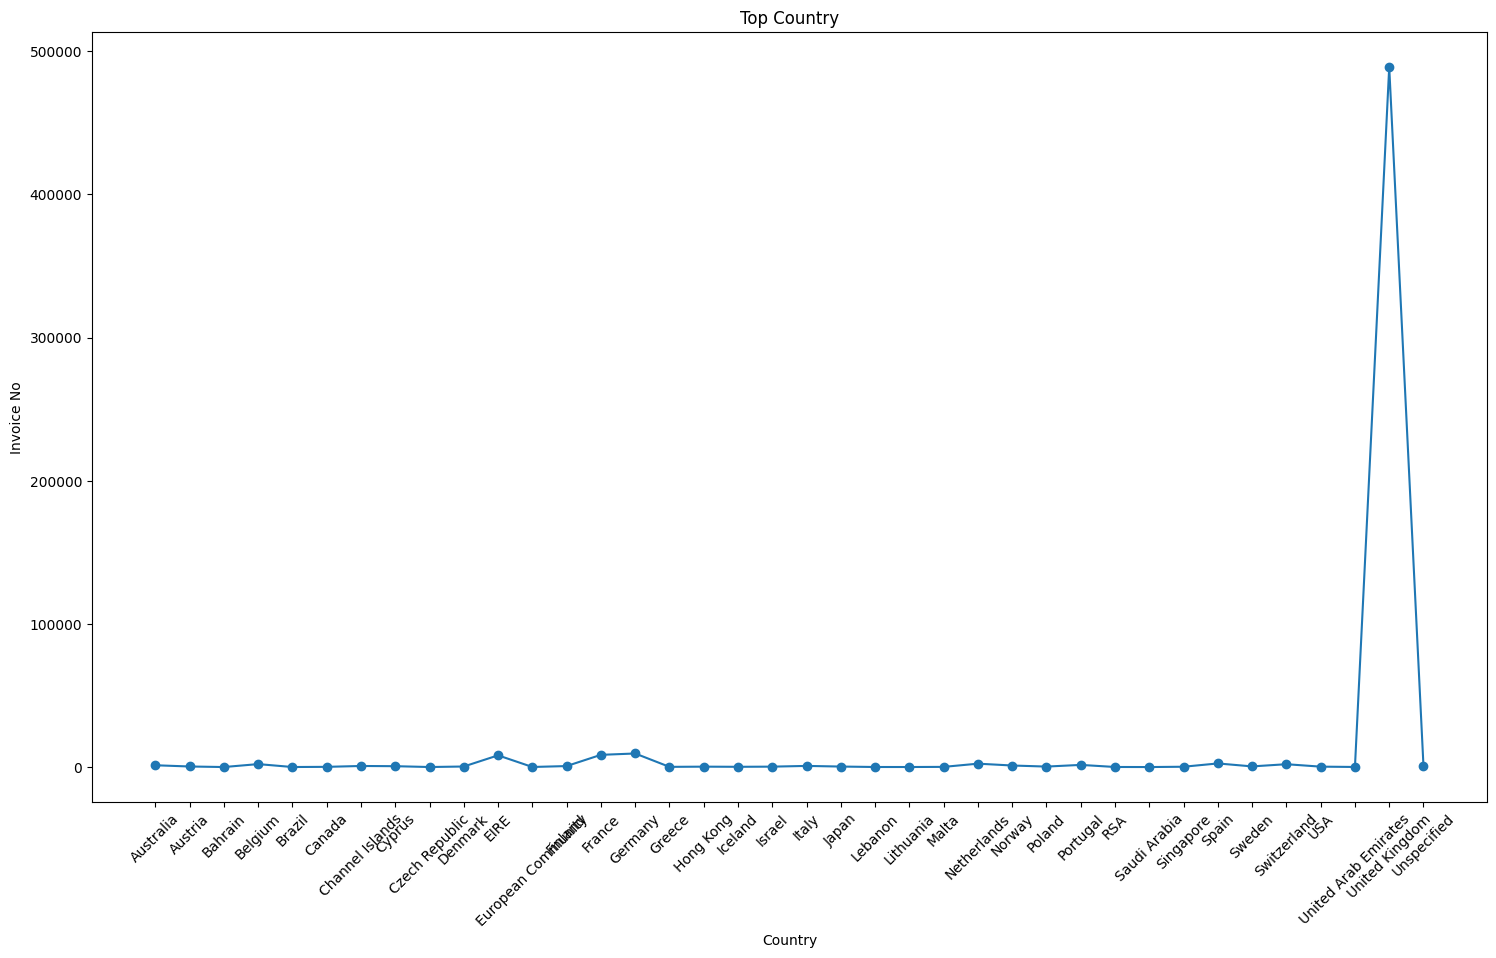

In [51]:
#Data Visualisation
maxsles_perCountry
#Matplotlib
#line Chart

plt.figure(figsize=(18,10))
plt.plot(maxsles_perCountry.index,maxsles_perCountry.values, marker='o')
plt.title("Top Country")
plt.xlabel('Country')
plt.ylabel('Invoice No')

plt.xticks(rotation=45)

plt.show()



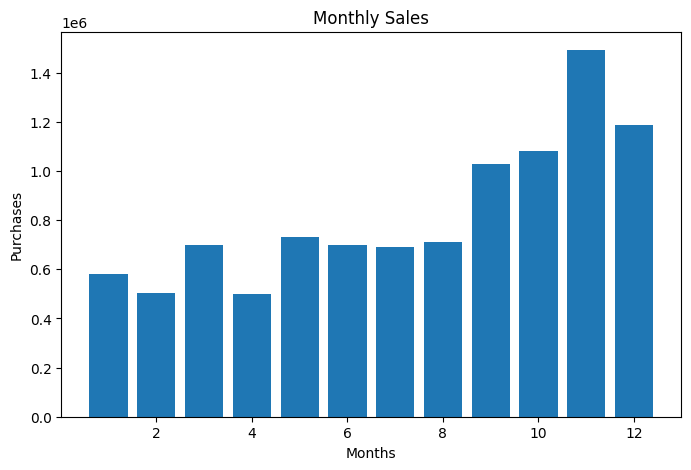

In [52]:
#bar chart
plt.figure(figsize=(8,5))
plt.bar(monthly_sales.index,monthly_sales.values)
plt.title("Monthly Sales")
plt.xlabel("Months")
plt.ylabel("Purchases")
plt.show()

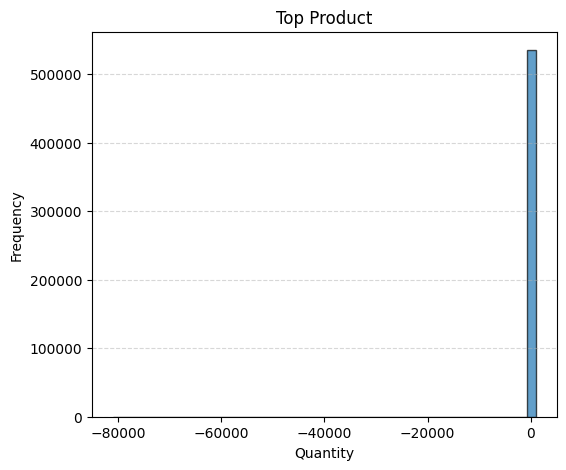

In [53]:
#Histogram
plt.figure(figsize=(6,5))
plt.hist(x=df[df['Quantity']<1000]['Quantity'],bins=50,edgecolor='black',alpha=0.7)
plt.title("Top Product")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.grid(axis='y',linestyle='--',alpha=0.5)
plt.show()

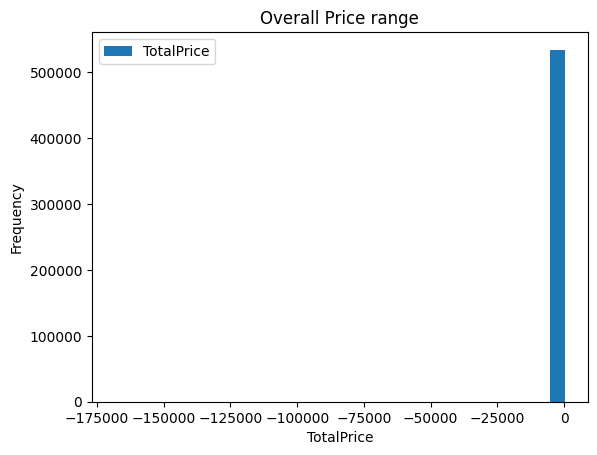

In [54]:
#Histogram for unitPrice

df[df['TotalPrice']<500].plot(kind='hist',y='TotalPrice',bins=30)
plt.title("Overall Price range")
plt.xlabel("TotalPrice")
plt.show()

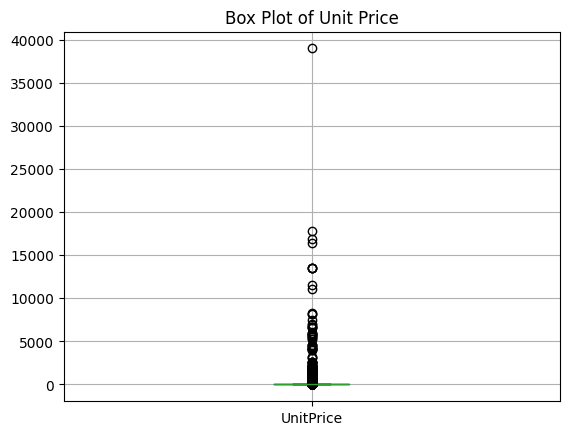

In [55]:
#box plot
df.boxplot(column='UnitPrice')

plt.title('Box Plot of Unit Price')
plt.show()

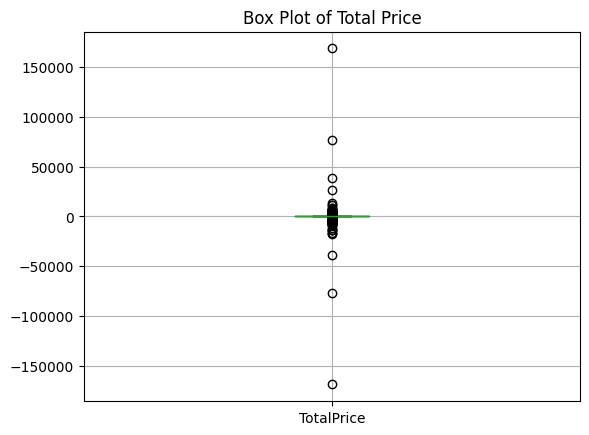

In [56]:
df.boxplot(column='TotalPrice')

plt.title('Box Plot of Total Price')
plt.show()

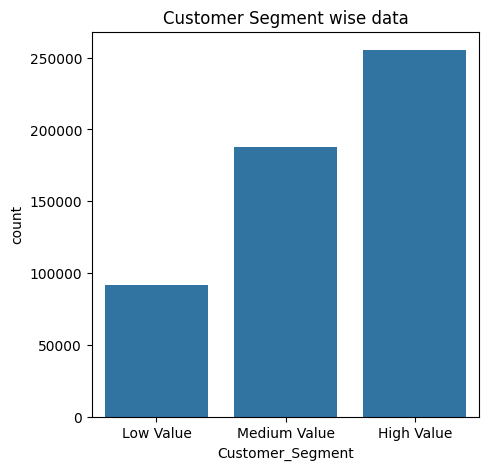

In [57]:
#Seaborn
import seaborn as sns
#Count Plot
plt.figure(figsize = (5,5))
sns.countplot(x = 'Customer_Segment', data = df)
plt.title("Customer Segment wise data")
plt.show()

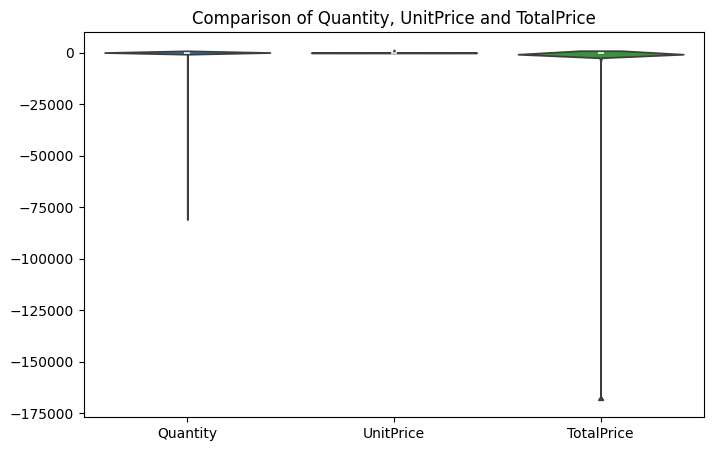

In [62]:
plot_data = df[
    (df['Quantity'] < 1000) &
    (df['UnitPrice'] < 1500) &
    (df['TotalPrice'] < 1000)
][['Quantity', 'UnitPrice', 'TotalPrice']]

plt.figure(figsize=(8,5))

sns.violinplot(data=plot_data)

plt.title("Comparison of Quantity, UnitPrice and TotalPrice")

plt.show()

In [64]:
numeric_df = df.select_dtypes(include=['int64','float64'])


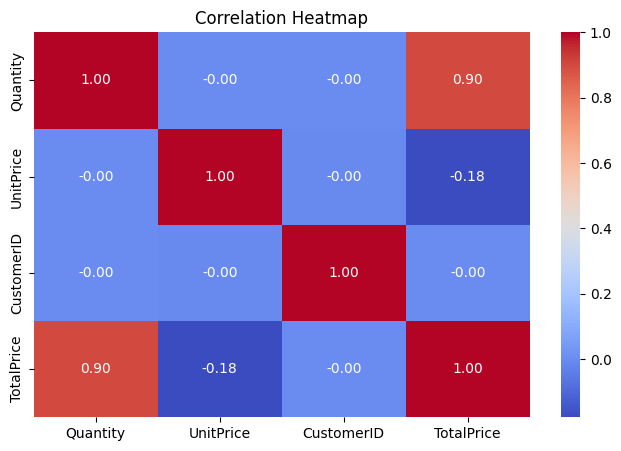

In [65]:
#heatmap
plt.figure(figsize = (8,5))

sns.heatmap(numeric_df.corr(), annot = True, fmt='.2f',cmap = 'coolwarm')
plt.title("Correlation Heatmap")
plt.show()

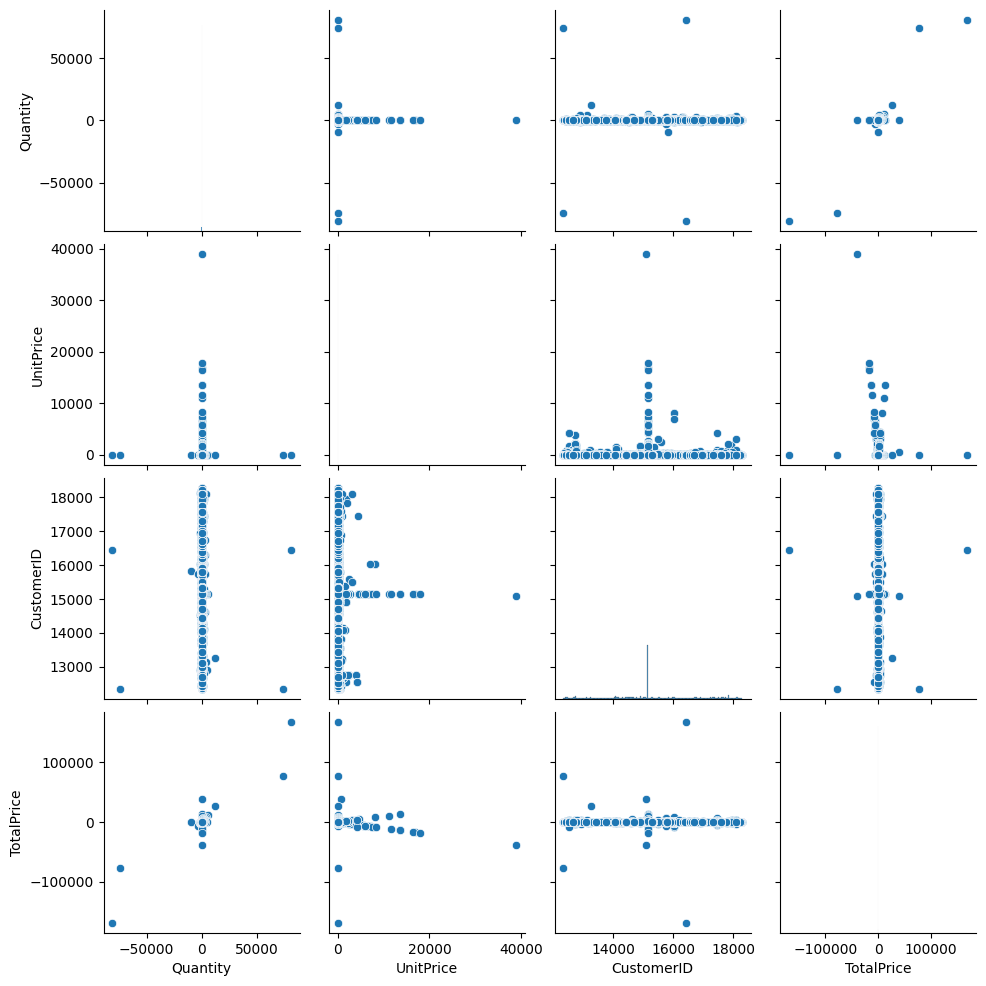

In [66]:
#pairplot
sns.pairplot(numeric_df)
plt.show()

In [67]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,Customer_Segment,Order_Size,Day_Type
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,High Value,Very Low Order,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,High Value,Very Low Order,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,High Value,Very Low Order,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,High Value,Very Low Order,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,High Value,Very Low Order,Wednesday


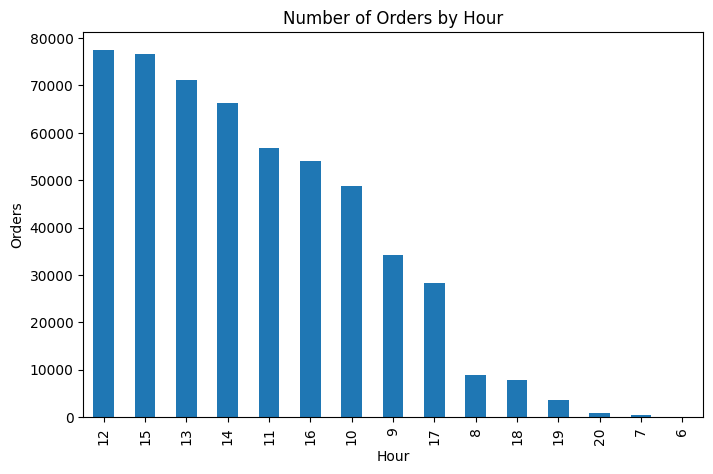

In [72]:
#Peak Sales Time

hourly_sales = (
    df.groupby('Hour')['InvoiceNo']
      .count()
      .sort_values(ascending=False)
)

hourly_sales.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Number of Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.show()

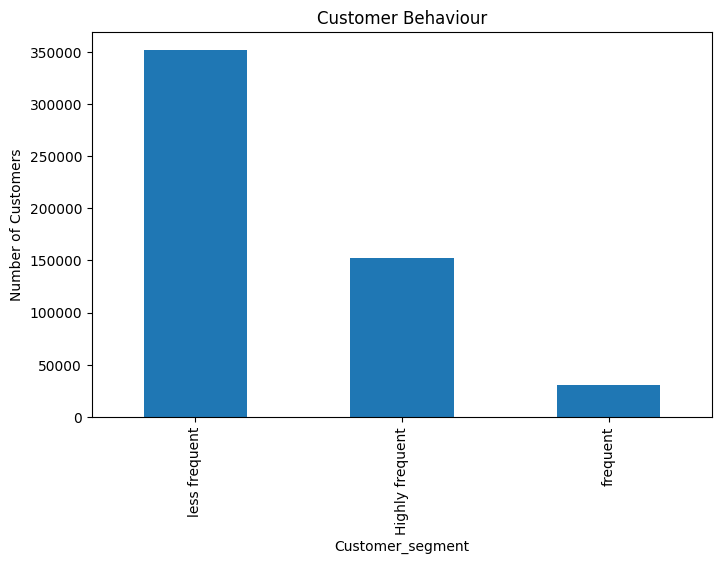

In [102]:
#Customer Behaviour
Customer_types = (
    df.groupby('customer_Segment')['CustomerID']
      .count()
      .sort_values(ascending=False)
)

Customer_types.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Customer Behaviour")
plt.xlabel("Customer_segment")
plt.ylabel("Number of Customers")
plt.show()


In [103]:
#customers by revenue
high_value_customers = (
    df.groupby('CustomerID')['TotalPrice']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(high_value_customers)

CustomerID
15152    1597593.19
14646     280698.62
18102     256438.49
17450     187322.17
14911     132983.73
12415     124347.05
14156     113214.59
17511      88125.38
16684      65892.08
13694      62690.54
Name: TotalPrice, dtype: float64


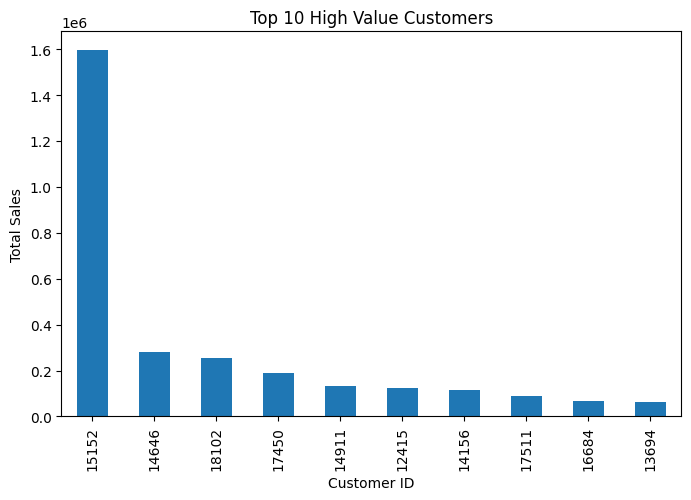

In [104]:
high_value_customers.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Top 10 High Value Customers")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.show()

In [105]:
top_products = (
    df.groupby('Description')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Description
WHITE HANGING HEART T-LIGHT HOLDER    67845
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47260
POPCORN HOLDER                        36322
ASSORTED COLOUR BIRD ORNAMENT         36282
PACK OF 72 RETROSPOT CAKE CASES       36016
RABBIT NIGHT LIGHT                    30631
MINI PAINT SET VINTAGE                26437
PACK OF 12 LONDON TISSUES             26299
PACK OF 60 PINK PAISLEY CAKE CASES    24719
Name: Quantity, dtype: int64


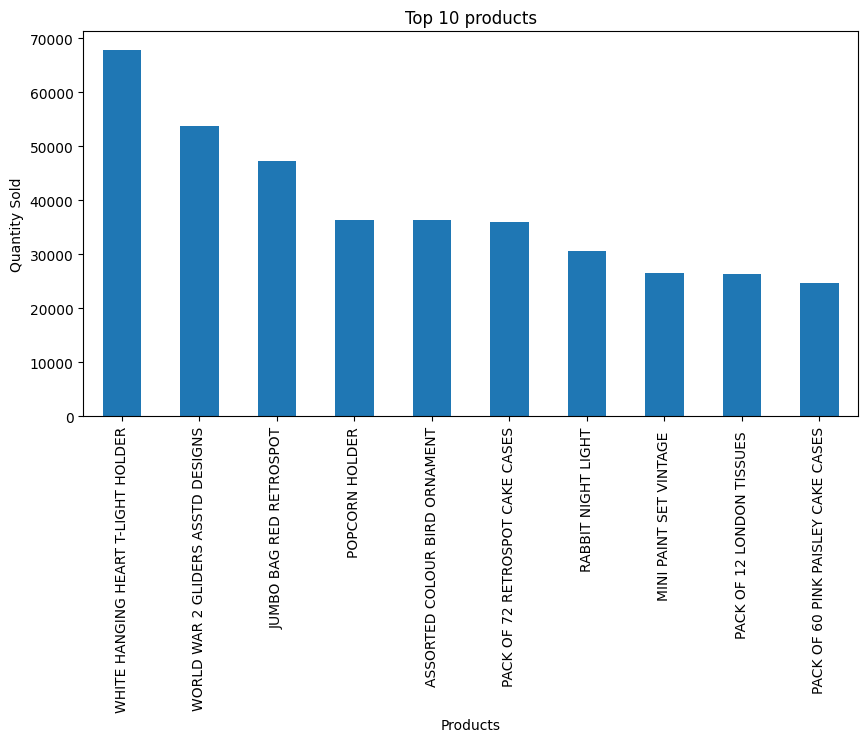

In [109]:
top_products.plot(kind='bar',figsize=(10,5))
plt.title("Top 10 products")
plt.xlabel('Products')
plt.ylabel('Quantity Sold')

plt.show()

Business Insights.

The Top most country which has contributed to maximum purshase of products is United Kingdom, with 488962 transaction count.
The month which has the most sales is November
The peak sales hour ranges from 12 noon to afternoon and reduces during night. 




Customer Behaviour

When we compare the customers vs No of transactions, we can classify them into less frequent, frequent, and highly frequent. Maximum of the customers fall into the - less frequent segment. The top most customer has done transactions for 1597593.19, which is a high contribution to our revenue.
Top product is WHITE HANGING HEART T-LIGHT HOLDER and with 67845 units sold.
